## Data Visualisation II

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Dataset Link

df_1 = pd.read_excel(r"C:\Users\Alfred\Desktop\Data Science Learning\Ultimate Data Science & GenAI,Agentic AI Bootcamp\practical_live\level_2\07-03-2026\online_retail_II.xlsx", sheet_name="Year 2009-2010")
df_1

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [4]:
df_2 = pd.read_excel(r"C:\Users\Alfred\Desktop\Data Science Learning\Ultimate Data Science & GenAI,Agentic AI Bootcamp\practical_live\level_2\07-03-2026\online_retail_II.xlsx", sheet_name="Year 2010-2011")
df_2

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
df = pd.concat([df_1, df_2], ignore_index=True)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
### removing null customer id rows
df= df.dropna(subset=["Customer ID"])
df.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Description  824364 non-null  object        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[us]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 56.6+ MB


In [7]:
## removing zero and negative quantities

df = df[df["Quantity"]> 0]
df.shape

(805620, 8)

In [8]:
## removing negative prices
df = df[df["Price"]> 0]
df.shape

(805549, 8)

In [9]:
df["Revenue"] = df["Quantity"] * df["Price"]
df.info

<bound method DataFrame.info of         Invoice StockCode                          Description  Quantity  \
0        489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1        489434    79323P                   PINK CHERRY LIGHTS        12   
2        489434    79323W                  WHITE CHERRY LIGHTS        12   
3        489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4        489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...         ...       ...                                  ...       ...   
1067366  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
1067367  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
1067368  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
1067369  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
1067370  581587      POST                              POSTAGE         1   

                InvoiceDate  Price  Customer ID        

In [10]:
## convert invoice date to proper date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [11]:
## creating another column as month and year from invoicedate
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [12]:
df["Year"] = df["InvoiceDate"].dt.year
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
 9   Month        805549 non-null  str           
 10  Year         805549 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(1), int64(1), object(3), str(2)
memory usage: 70.7+ MB


In [13]:
df["Month_no"] = df["InvoiceDate"].dt.month
df.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[us]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  str           
 8   Revenue      805549 non-null  float64       
 9   Month        805549 non-null  str           
 10  Year         805549 non-null  int32         
 11  Month_no     805549 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(2), int64(1), object(3), str(2)
memory usage: 73.8+ MB


In [14]:
## find monthly revenue
## Use Group revenue by month
## sum revenue
monthly_revenue_groupby = df.groupby("Month")["Revenue"].sum()
monthly_revenue_groupby

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Name: Revenue, dtype: float64

In [15]:
## scatter plot relationship between revenue and quantity

sample_df = df.sample(1000, random_state=10000)
sample_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Year,Month_no
889181,568576,22993,SET OF 4 PANTRY JELLY MOULDS,72,2011-09-28 09:40:00,1.06,17017.0,United Kingdom,76.32,2011-09,2011,9
579860,540946,20704,MR ROBOT SOFT TOY,8,2011-01-12 12:43:00,1.95,12359.0,Cyprus,15.60,2011-01,2011,1
188131,507243,22558,CLOTHES PEGS RETROSPOT PACK 24,12,2010-05-07 10:19:00,1.25,15312.0,United Kingdom,15.00,2010-05,2010,5
857557,566057,47341B,BLUE TABLE RUN FLOWER,6,2011-09-08 15:16:00,1.25,17997.0,United Kingdom,7.50,2011-09,2011,9
423556,529849,22111,SCOTTIE DOG HOT WATER BOTTLE,3,2010-10-31 13:28:00,4.95,14114.0,United Kingdom,14.85,2010-10,2010,10


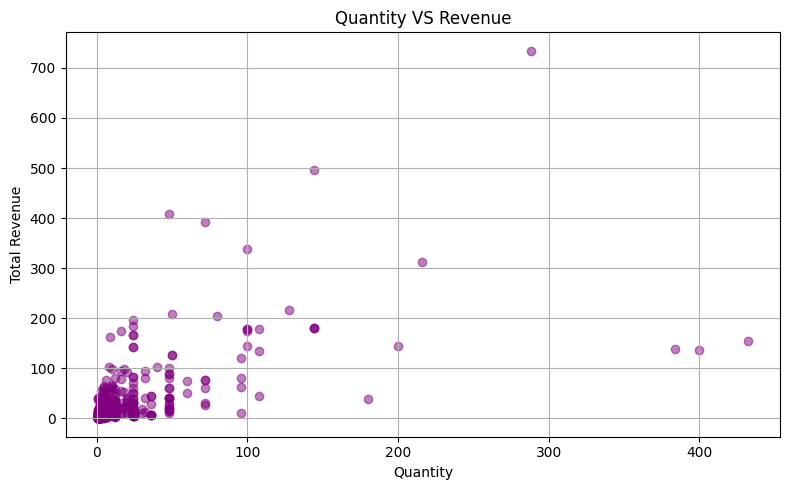

In [16]:
from numpy.random.mtrand import sample
plt.figure(figsize = (8,5))

plt.scatter(sample_df["Quantity"], sample_df["Revenue"], alpha=0.5, color= "purple")
plt.title("Quantity VS Revenue")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.grid(True)
plt.show()

In [17]:
# monthly_revenue_groupby.head()
monthly_quantity = df.groupby("Month")["Quantity"].sum().sort_index()
monthly_quantity

Month
2009-12    400153
2010-01    370921
2010-02    372761
2010-03    503466
2010-04    352025
2010-05    386297
2010-06    391674
2010-07    325655
2010-08    453581
2010-09    568612
2010-10    598523
2010-11    656318
2010-12    470633
2011-01    349098
2011-02    265622
2011-03    348503
2011-04    292222
2011-05    373601
2011-06    363699
2011-07    369420
2011-08    398121
2011-09    544897
2011-10    593900
2011-11    669051
2011-12    287414
Name: Quantity, dtype: int64

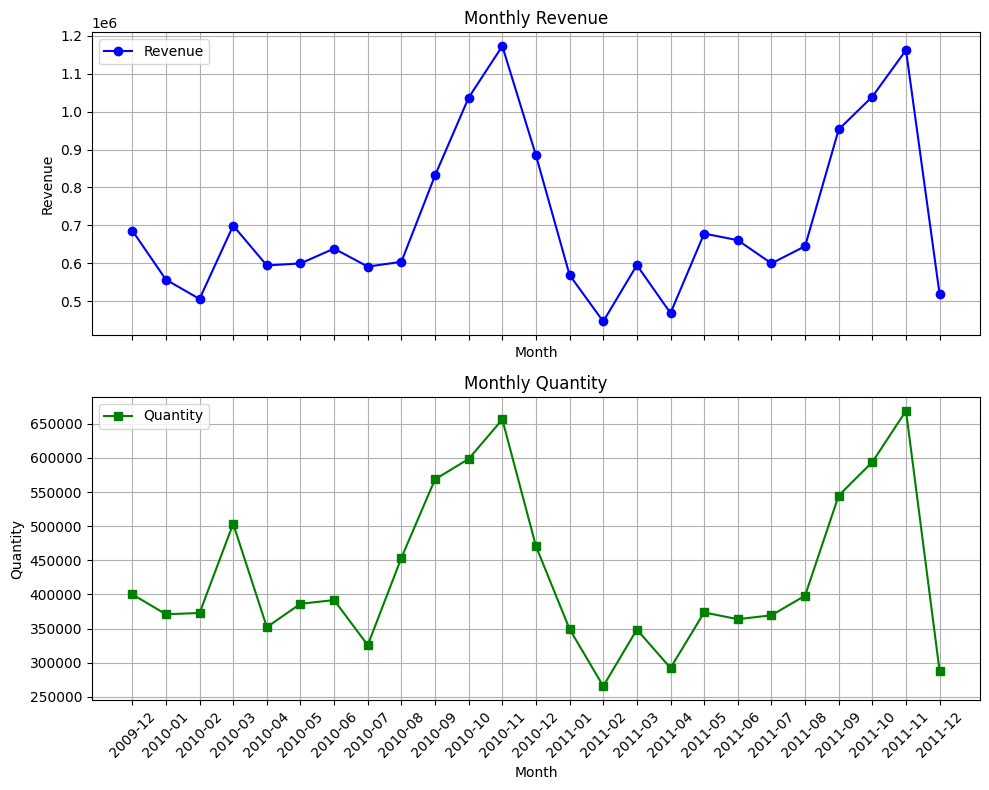

In [18]:
fig, axs = plt.subplots(nrows = 2, ncols=1, figsize= (10,8), sharex=True)

## revenue plot
axs[0].plot(monthly_revenue_groupby.index, monthly_revenue_groupby.values, marker = "o", color= "blue", label = "Revenue")
axs[0].set_title("Monthly Revenue")
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Revenue")
axs[0].legend()
axs[0].grid(True)

## quantity plot
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker = "s", color= "green", label = "Quantity")
axs[1].set_title("Monthly Quantity")
axs[1].set_xlabel("Month")
axs[1].set_ylabel("Quantity")
axs[1].legend()
axs[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

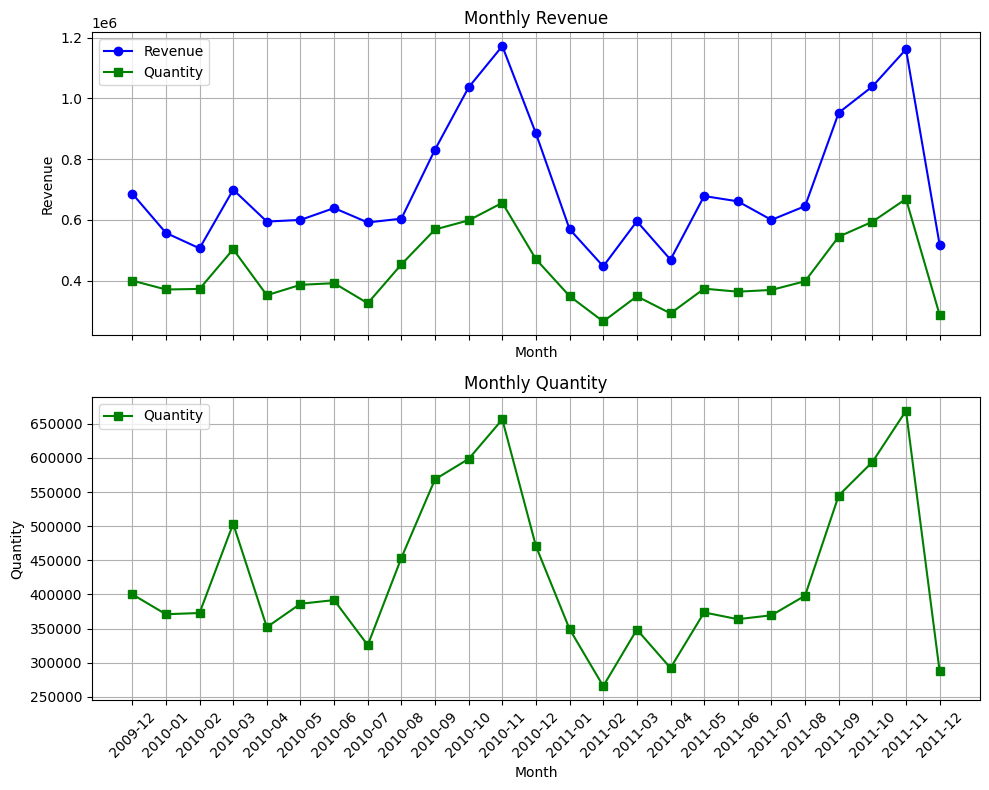

In [19]:
fig, axs = plt.subplots(nrows = 2, ncols=1, figsize= (10,8), sharex=True)

## revenue plot
axs[0].plot(monthly_revenue_groupby.index, monthly_revenue_groupby.values, marker = "o", color= "blue", label = "Revenue")
axs[0].plot(monthly_quantity.index, monthly_quantity.values, marker = "s", color= "green", label = "Quantity")
axs[0].set_title("Monthly Revenue")
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Revenue")
axs[0].legend()
axs[0].grid(True)

## quantity plot
axs[1].plot(monthly_quantity.index, monthly_quantity.values, marker = "s", color= "green", label = "Quantity")
axs[1].set_title("Monthly Quantity")
axs[1].set_xlabel("Month")
axs[1].set_ylabel("Quantity")
axs[1].legend()
axs[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
plt.figure(figsize=(12,6))

plt.plot(monthly_revenue_groupby.index, monthly_revenue_groupby.values, marker = "o")
plt.title("Monthly revenue over time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig("Monthly_revenue_plot.png",dpi=300)
plt.close()

# Seaborn 

In [21]:
import seaborn as sns

In [22]:
## New analysis : Distribution of quantity by transaction

df_quantity = df[(df["Quantity"] > 0) & (df["Quantity"] < 100)]
df_quantity.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Year,Month_no
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009,12


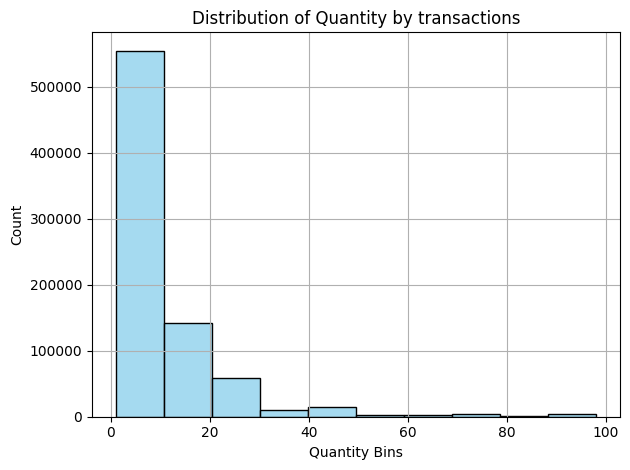

In [24]:

plt.Figure(figsize=(12,6))
sns.histplot(data= df_quantity["Quantity"], bins= 10, kde=False, color="skyblue")
plt.title("Distribution of Quantity by transactions")
plt.xlabel("Quantity Bins")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(True)
plt.show()

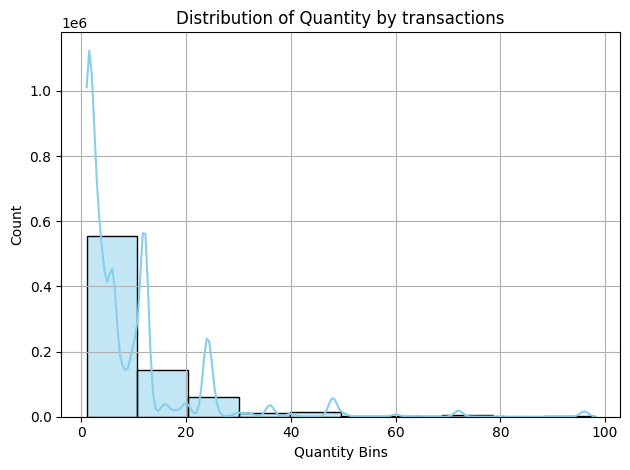

In [28]:
## Enabling density (kde) -  the probability of getting that particular Bin
plt.Figure(figsize=(12,6))
sns.histplot(data= df_quantity["Quantity"], bins= 10, kde=True, color="skyblue")
plt.title("Distribution of Quantity by transactions")
plt.xlabel("Quantity Bins")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(True)
plt.show()

#### Enabling density (kde-kernel density estimate) -  the probability of getting that particular Bin
- it tells us what is the probability of a value falling between 0-10 bin, 10-20 bin etc and
- thats the density of each unit of the bin

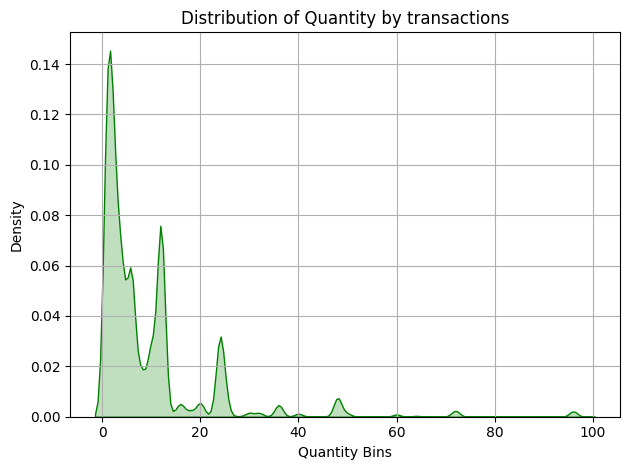

In [29]:
### creating a kdeplot only

plt.Figure(figsize=(12,8))
sns.kdeplot(data= df_quantity["Quantity"], fill=True, color="green")
plt.title("Distribution of Quantity by transactions")
plt.xlabel("Quantity Bins")
##plt.ylabel("Count")
plt.tight_layout()
plt.grid(True)
plt.show()

In [30]:
df_sample = df[["Quantity", "Price", "Revenue", "Country", "Month"]].copy()

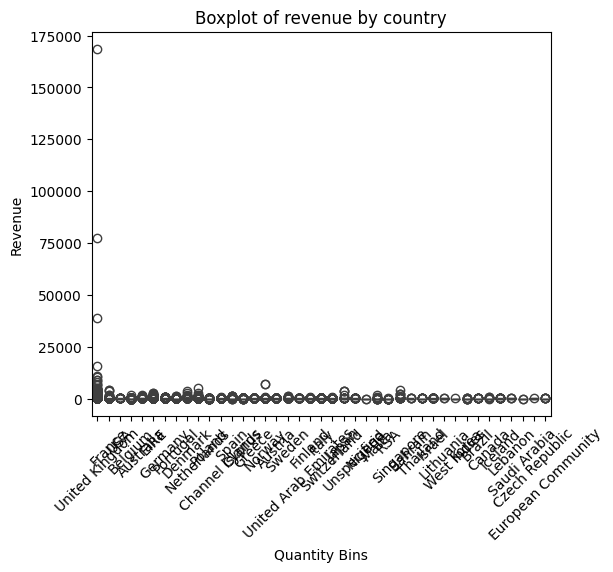

In [ ]:
plt.Figure(figsize=(14,6))
sns.boxplot(data= df_sample, x= "Country", y="Revenue")
plt.title("Boxplot of revenue by country")
#plt.xlabel("Quantity Bins")
plt.ylabel("Revenue")
plt.tight_layout()
plt.xticks(rotation=45)
##plt.grid(True)
plt.show()

In [41]:
df_revenue_sample = df[(df["Revenue"] > 1000) & (df["Quantity"] < 2000)]
df_revenue_sample.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Year,Month_no
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,1160.0,2009-12,2009,12
3290,489675,15056BL,EDWARDIAN PARASOL BLACK,240,2009-12-02 09:47:00,4.60,13777.0,United Kingdom,1104.0,2009-12,2009,12
4793,489831,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-02 13:58:00,2.10,12435.0,Denmark,1008.0,2009-12,2009,12
6443,489889,85123A,WHITE HANGING HEART T-LIGHT HOLDER,480,2009-12-02 16:52:00,2.55,14646.0,Netherlands,1224.0,2009-12,2009,12
7007,490010,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,480,2009-12-03 12:15:00,2.10,15061.0,United Kingdom,1008.0,2009-12,2009,12


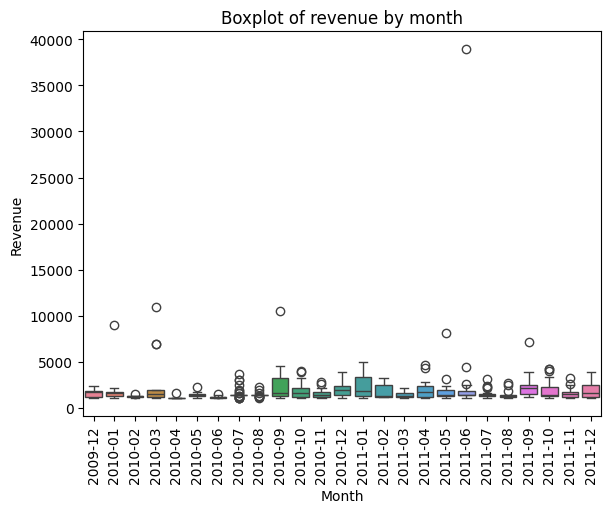

In [43]:
plt.Figure(figsize=(18,10))
sns.boxplot(data= df_revenue_sample, x= "Month", y="Revenue", hue="Month")
plt.title("Boxplot of revenue by month")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

#### Categorical Data Visualization

In [44]:
##Top countries by revenue

top_countries_by_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
top_countries_by_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

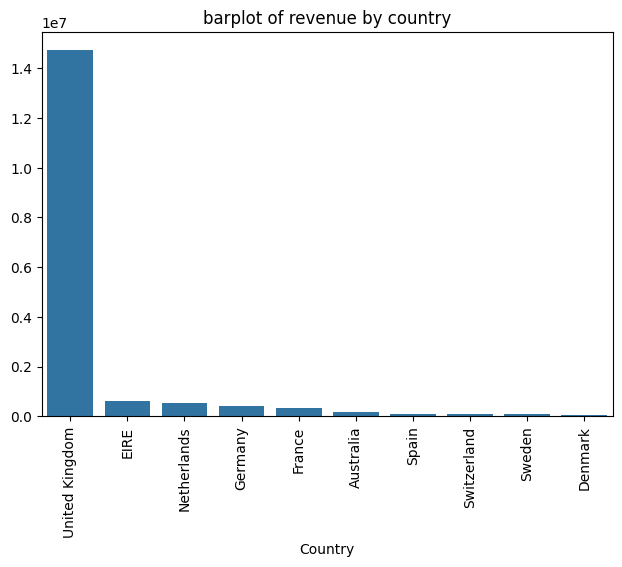

In [52]:
plt.Figure(figsize=(18,10))
sns.barplot(x= top_countries_by_revenue.index, y=top_countries_by_revenue.values )
plt.title("barplot of revenue by country")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

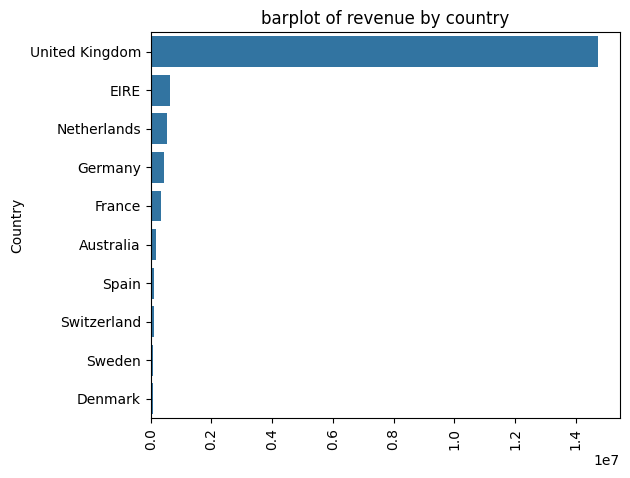

In [53]:
plt.Figure(figsize=(18,10))
sns.barplot(y= top_countries_by_revenue.index, x=top_countries_by_revenue.values )
plt.title("barplot of revenue by country")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

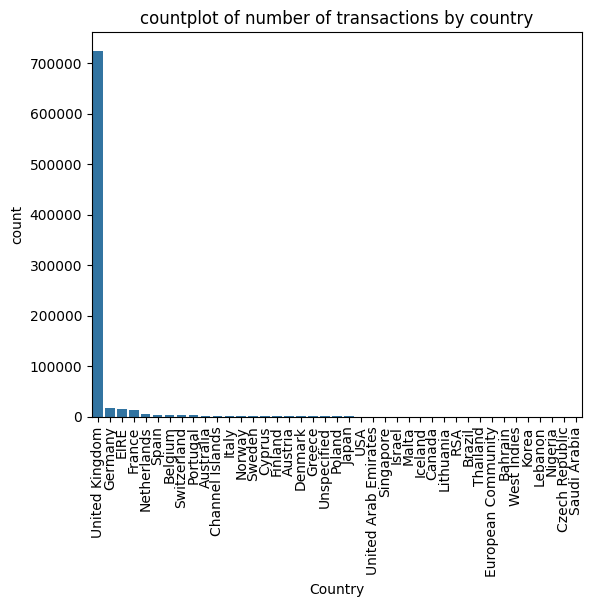

In [55]:
## number of transactions by country

plt.Figure(figsize=(18,10))
sns.countplot(data= df_sample ,x= "Country",order=df_sample["Country"].value_counts().index )
plt.title("countplot of number of transactions by country")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [ ]:
### top 5 countries by number of transactions

transactions_per_country = df["Country"].value_counts().head(5)
print(transactions_per_country)








Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Name: count, dtype: int64


In [59]:
df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(5)


Country
United Kingdom    33541
Germany             789
France              614
EIRE                567
Netherlands         228
Name: Invoice, dtype: int64

In [60]:
## top 5 countries by number of row present
# filter only rows that have this 5 countries
# group by country and month 

top_countries = df["Country"].value_counts().head(5).index.tolist()
df_top = df[df["Country"].isin(top_countries)].copy()
grouped = df_top.groupby(["Country", "Month"])["Revenue"].sum().reset_index()
grouped

,Country,Month,Revenue
0,EIRE,2009-12,18170.460
1,EIRE,2010-01,65031.410
2,EIRE,2010-02,20206.460
3,EIRE,2010-03,22989.460
4,EIRE,2010-04,20668.080
...,...,...,...
120,United Kingdom,2011-08,498453.320
121,United Kingdom,2011-09,796780.272
122,United Kingdom,2011-10,824766.220
123,United Kingdom,2011-11,980645.750


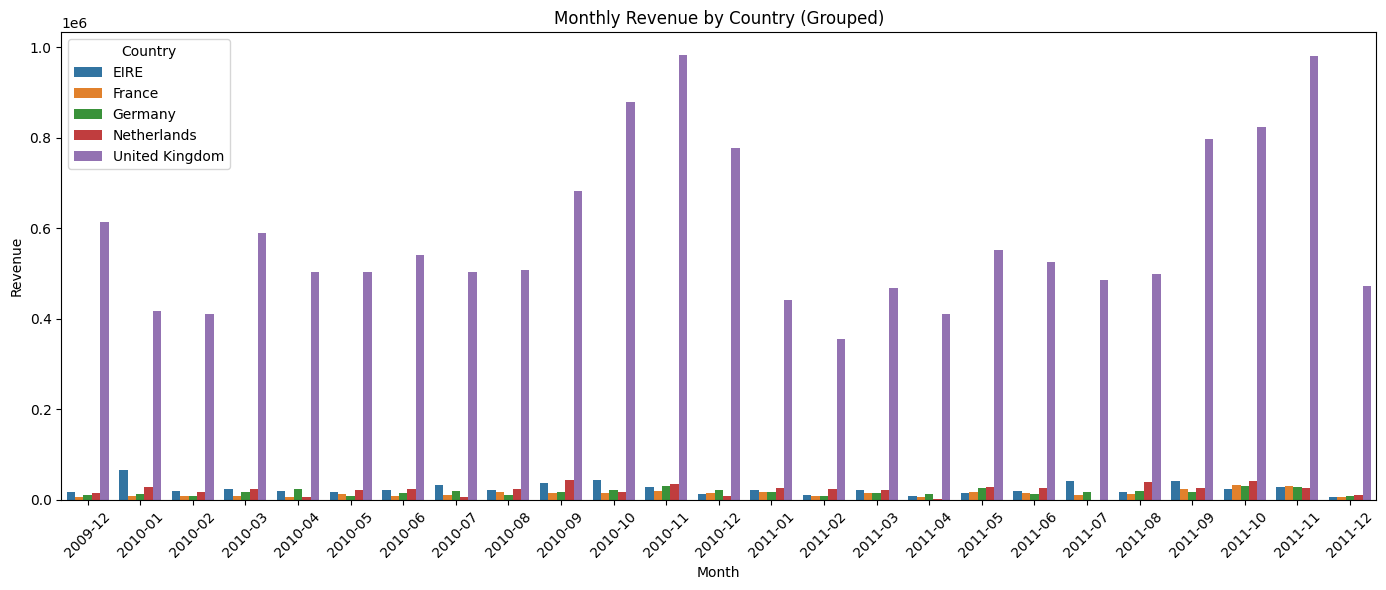

In [68]:
# 1. Grouped Bar Plot using Seaborn

plt.figure(figsize=(14, 6))
sns.barplot(data=grouped, x='Month', y='Revenue', hue='Country')
plt.title('Monthly Revenue by Country (Grouped)')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Country')
plt.show()

c:\Users\Alfred\Desktop\Data Science Learning\Ultimate Data Science & GenAI,Agentic AI Bootcamp\practical_live\level_2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


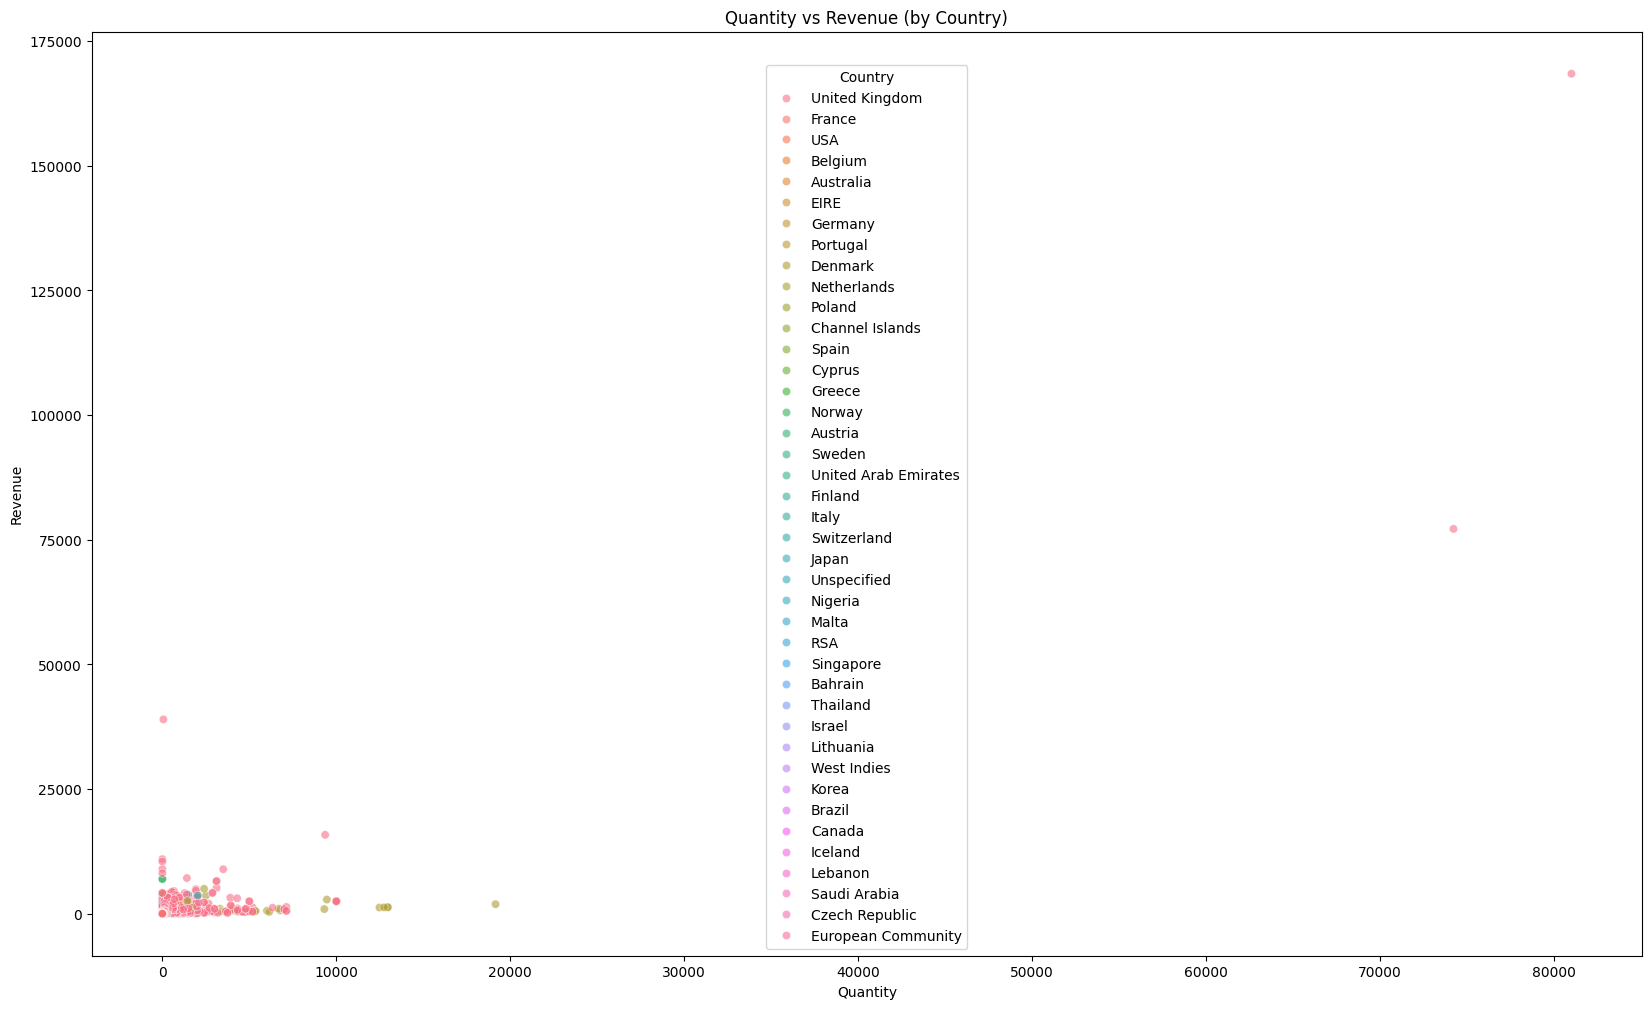

In [69]:
## Scatter plots

plt.figure(figsize=(20, 12))
sns.scatterplot(data=df_sample, x='Quantity', y='Revenue', hue='Country', alpha=0.6)
plt.title("Quantity vs Revenue (by Country)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

In [70]:
#### filtered data

df_filtered = df_sample[(df_sample['Quantity'] > 0) &
                        (df_sample['Quantity'] < 5000) &
                        (df_sample['Revenue'] < 10000) &
                        (df_sample['Revenue'] > 0)]


top_countries = df_filtered['Country'].value_counts().head(5).index
df_filtered = df_filtered[df_filtered['Country'].isin(top_countries)]

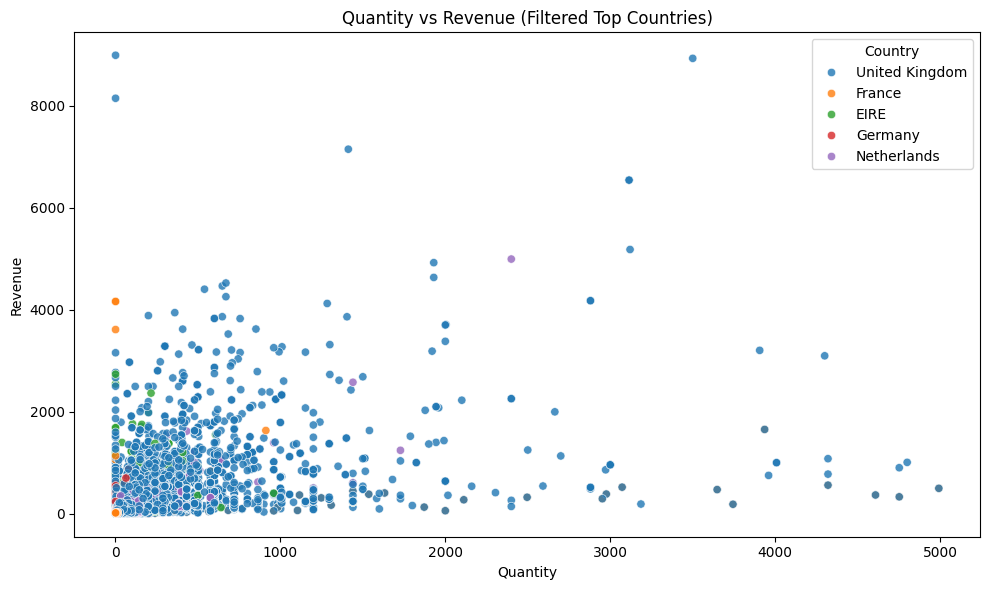

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Quantity', y='Revenue', hue='Country', alpha=0.8)
plt.title("Quantity vs Revenue (Filtered Top Countries)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

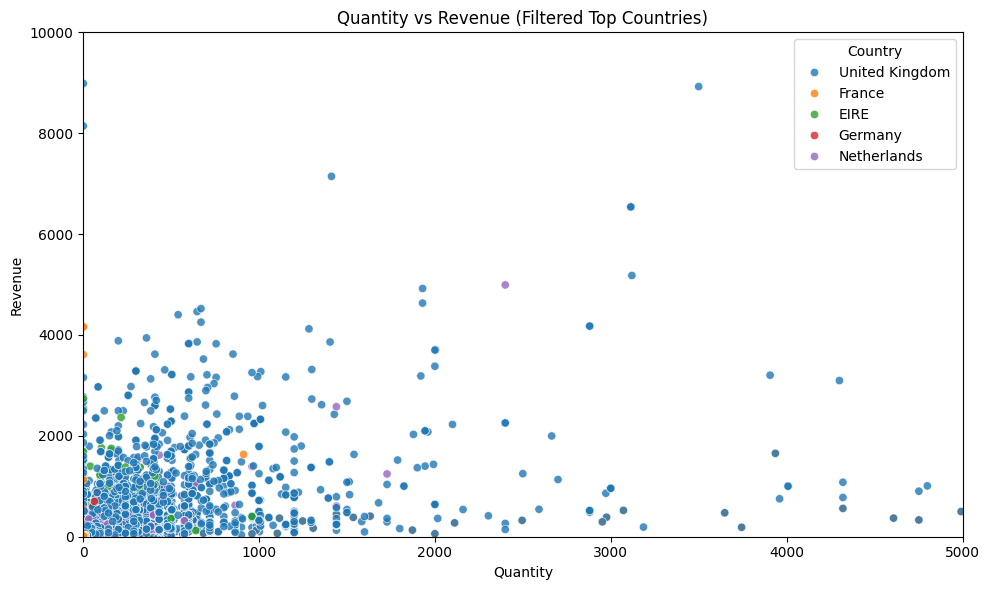

In [72]:
### adding limits where it should start and end from xlim and ylim

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Quantity', y='Revenue', hue='Country', alpha=0.8)
plt.title("Quantity vs Revenue (Filtered Top Countries)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.xlim(0, 5000)
plt.ylim(0, 10000)

plt.tight_layout()
plt.show()

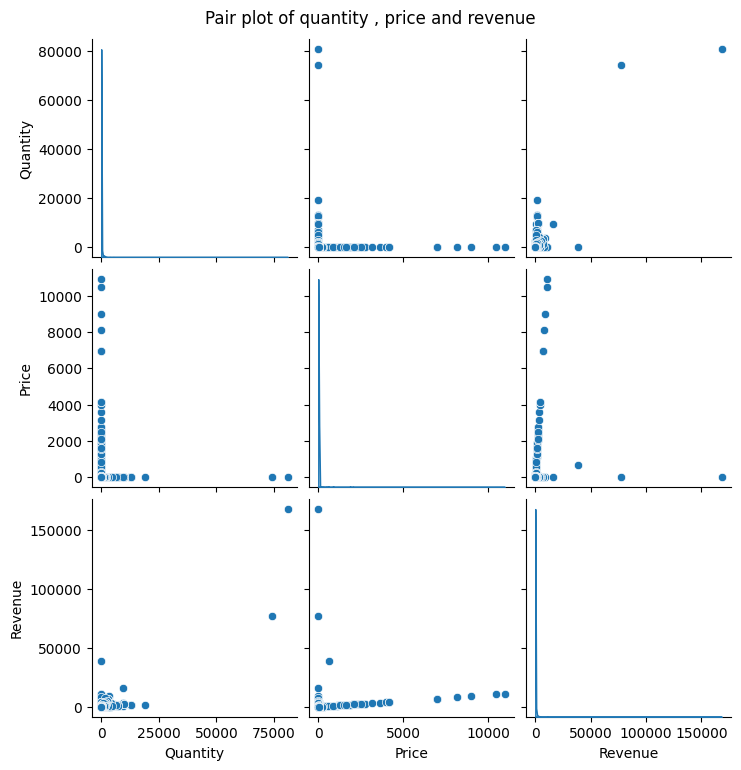

In [62]:
## Pairs of plots -  
### quantity , price and revenue

sns.pairplot(df_sample[["Quantity", "Price", "Revenue"]],diag_kind="kde" )
plt.suptitle("Pair plot of quantity , price and revenue", y=1.02)
# plt.tight_layout()
# plt.xticks(rotation=90)
plt.show()

### sns.heatmap() Correlation Matrix

In [65]:
corr_matrix = df_sample[["Quantity", "Price", "Revenue"]].corr()
corr_matrix

,Quantity,Price,Revenue
Quantity,1.000000,-0.004909,0.826590
Price,-0.004909,1.000000,0.135897
Revenue,0.826590,0.135897,1.000000


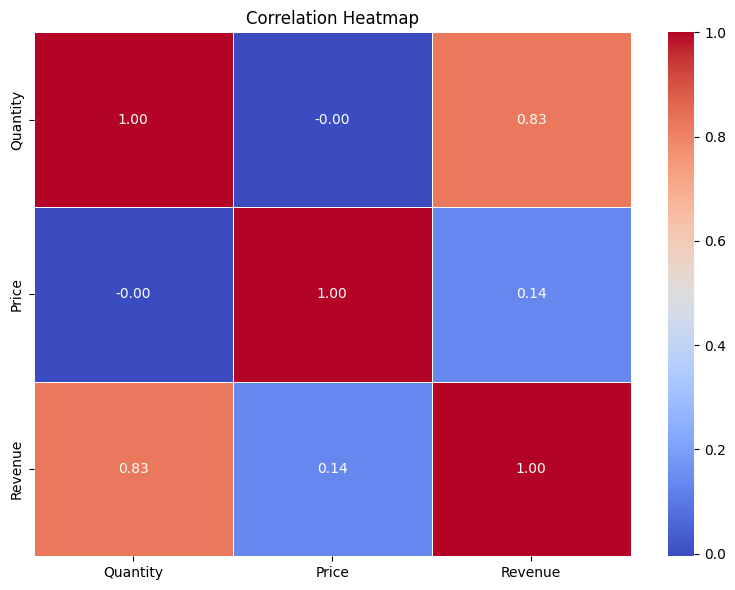

In [66]:
### Seaborn Correlation Matrix  - sns.heatmap()

#corr_matrix = df_sample[["Quantity", "Price", "Revenue"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation values
    cmap="coolwarm",   # color scale
    fmt=".2f",         # format numbers
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

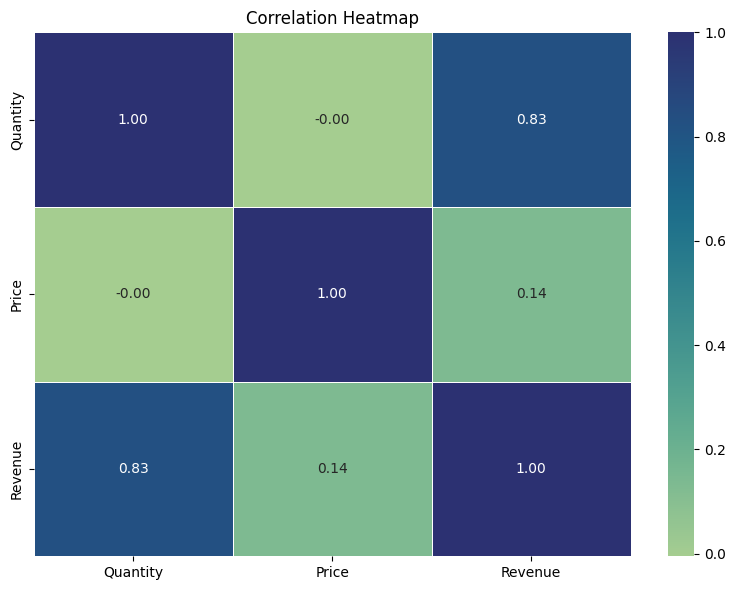

In [67]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,annot=True, cmap="crest",fmt=".2f",linewidths=0.5 )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()